In [23]:
import numpy as np
import pandas as pd
import subprocess
from pathlib import Path
import matplotlib.pyplot as plt

In [24]:

msname=["MSbookflightsEntry","MScancelbookingEntry","MSviewprofileEntry",
        "MSupdateprofileEntry","MSupdateMilesEntry","MSvalidateidEntry",
        "MSqueryflightsEntry","MSgetrewardmilesEntry","MSauthEntry"]

### Columns
#Each column corresponds to a metric:
#- 0 - CPU_Usage (GoogleCloud metric)
#- 1 - RPS (Custom metric)
#- 2 - Service_Time (Custom metric)
#- 3 - Response_Time (Estimated with CPU_Usage / RPS)


In [27]:

for i in range(2,6):
    data=[]
    #read model data
    df=pd.read_csv(f"../acmeair_{i}.csv",names=['metric','type','name','value'])
    for ms in msname:
        util=df[(df["name"]==ms) & (df["metric"]=="proc utilization")]["value"].iloc[0]
        tr=df[(df["name"]==ms) & (df["metric"]=="throughput")]["value"].iloc[0]
        rt=df[(df["name"]==ms) & (df["metric"]=="response time")]["value"].iloc[0]*1000
        data+=[[util,tr,rt]]
    data=np.array(data)
    #read measurement
    mes=pd.read_csv(f"u1_u5-30m_average_results_AcmeAir_fast/u{i}-30m_avg_matrix.csv",names=['CPU_Usage',"Replicas","RPS","Response Time","Service_Time"]).to_numpy()
    e=np.divide(np.abs(data[:,1]-mes[:,2]),mes[:,2])*100
    print(e)

#print(mes)

[0.72017747 0.28957899 0.54358272 0.21169694 0.56316938 0.68087289
 0.56316425 0.48484741 0.99611636]
[3.40213576 2.64898639 2.45270727 2.89320637 2.45271196 2.25565257
 3.30561599 3.23309195 2.05778949]
[2.47728848 3.26332269 3.4533327  3.00878797 3.46236714 3.62462102
 2.67958534 2.67958207 3.44431158]
[4.25753522 3.88666132 3.77196604 4.11523034 3.77196775 3.59941174
 4.37107446 4.43128348 3.31044116]


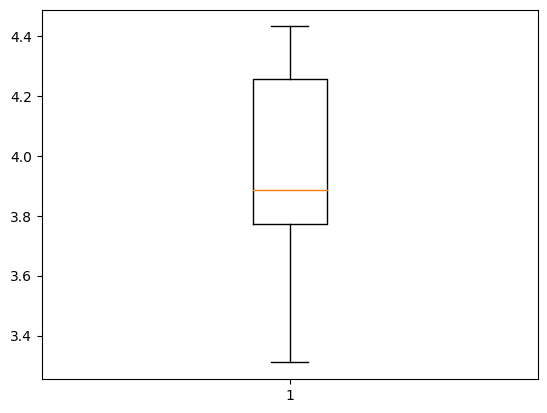

In [28]:
plt.figure()
plt.boxplot(e)
plt.show()